# Math 280: Mathematical and Statistical Foundations of Data Science
## Week 10 — Decision Trees, Pruning, and Ensemble Methods
### UC Merced | Spring 2026 | S. Sindi

---

This notebook walks you through the core ideas from the Week 10 lecture notes, with one running example from start to finish. You will see four methods applied to the same dataset, with the decision boundary plotted for each one.

**Run every cell in order. Read the text between cells carefully — it explains what you are seeing and why it matters.**

The four methods we will compare:

| Method | Key idea |
|--------|----------|
| Full decision tree | Grow until every leaf is pure — zero training error, but overfits |
| Pruned decision tree | Limit `max_depth` to prevent overfitting |
| Logistic regression | Linear boundary — our baseline from earlier in the course |
| Random forest | Average many trees — smooth, low-variance boundary |

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

plt.rcParams.update({
    'figure.dpi': 110,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

SEED = 42
np.random.seed(SEED)

# Colours used throughout
C0, C1   = '#4878D0', '#EE854A'   # blue, orange
BG0, BG1 = '#EBF0FB', '#FDF2E9'   # light blue, light orange (background regions)

print('Ready.')

Ready.


---
## The Dataset

We use the **Two Moons** dataset: two interleaving crescent-shaped classes in $\mathbb{R}^2$. This is a synthetic dataset, which means we know exactly what the true boundary looks like — it follows the gap between the two crescents, which is a **curved** shape.

This is the key fact that will drive everything we observe:
- Logistic regression can only draw a **straight line**. On this data, it will struggle.
- A decision tree draws a **staircase** of horizontal and vertical cuts. With enough steps, it can approximate a curve.
- A random forest **averages many staircases**, producing a smoother boundary.

We use an **80/20 train/test split**: 80% of the data to fit each model, 20% held out to evaluate it. This gives us an honest estimate of how each model performs on new data.

Training samples : 240
Test samples     : 60


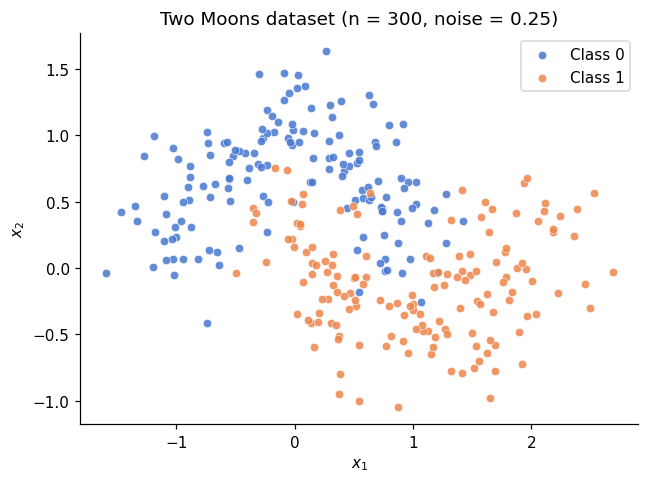

In [2]:
# Generate the dataset
X, y = make_moons(n_samples=300, noise=0.25, random_state=SEED)

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

# Plot the raw data
fig, ax = plt.subplots(figsize=(6, 4.5))
for k, (label, col) in enumerate(zip(['Class 0', 'Class 1'], [C0, C1])):
    mask = y == k
    ax.scatter(X[mask, 0], X[mask, 1], c=col, label=label,
               s=30, edgecolors='white', linewidths=0.4, alpha=0.85)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Two Moons dataset (n = 300, noise = 0.25)')
ax.legend()
plt.tight_layout()
plt.show()

The two classes interleave — no straight line separates them cleanly. Keep this shape in mind as you look at each method's boundary below.

### Decision boundary helper function

The following function will be used to visualise every model we fit. It evaluates the model on a fine grid of points, shades the predicted regions blue or orange, overlays the training and test data, and reports the test accuracy. You do not need to modify it — just run it.

In [3]:
def plot_boundary(clf, X_tr, y_tr, X_te, y_te, title='', ax=None):
    """
    Plot the 2-D decision boundary of a fitted binary classifier.

    Filled circles  = training points.
    Diamond markers = test points.
    Test accuracy is shown in the subtitle.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(5.5, 4.5))

    # Build a fine grid over the feature space
    pad = 0.35
    x1_min, x1_max = X_tr[:, 0].min() - pad, X_tr[:, 0].max() + pad
    x2_min, x2_max = X_tr[:, 1].min() - pad, X_tr[:, 1].max() + pad
    xx, yy = np.meshgrid(np.arange(x1_min, x1_max, 0.01),
                         np.arange(x2_min, x2_max, 0.01))

    # Predict every grid point and shade regions
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.40, cmap=ListedColormap([BG0, BG1]))
    ax.contour( xx, yy, Z, colors='dimgrey', linewidths=1.0, linestyles='--')

    # Training points (filled circles)
    for k, col in enumerate([C0, C1]):
        m = y_tr == k
        ax.scatter(X_tr[m, 0], X_tr[m, 1], c=col,
                   edgecolors='white', linewidths=0.4, s=28, alpha=0.9)

    # Test points (diamonds with black edge)
    for k, col in enumerate([C0, C1]):
        m = y_te == k
        ax.scatter(X_te[m, 0], X_te[m, 1], c=col, marker='D',
                   edgecolors='black', linewidths=0.7, s=25)

    test_acc = accuracy_score(y_te, clf.predict(X_te))
    ax.set_title(f'{title}\nTest accuracy: {test_acc:.1%}', fontsize=11)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    return ax

print('plot_boundary() defined.')

plot_boundary() defined.


---
## Method 1 — The Full Decision Tree

### What is a decision tree?

A decision tree classifies a point by asking a sequence of yes/no questions, each of the form:

> *Is feature $x_j$ less than threshold $s$?*

Each question splits the data into two groups. The algorithm chooses the split that most reduces **Gini impurity** — a measure of how mixed the class labels are in each resulting group. It then recurses on each group, asking further questions, until some stopping criterion is met.

Because every question is of the form $x_j < s$, the resulting decision boundary is always made up of **horizontal and vertical line segments** — a staircase shape.

### The full tree: growing until pure leaves

A **full tree** is grown with no stopping criterion: it keeps splitting until every leaf node contains only training points from a single class. At that point, training accuracy is exactly 100%.

This sounds ideal, but it is not. The tree has memorised the training data — including any noise in it. When we apply it to new test points, it will make errors in regions where it carved out tiny leaf nodes to accommodate individual noisy training points. This is **overfitting**.

In [4]:
# Fit the full tree — no depth limit, grow until every leaf is pure
tree_full = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=SEED)
tree_full.fit(X_train, y_train)

print(f'Tree depth        : {tree_full.get_depth()}')
print(f'Number of leaves  : {tree_full.get_n_leaves()}')
print(f'Training accuracy : {tree_full.score(X_train, y_train):.1%}')
print(f'Test accuracy     : {tree_full.score(X_test,  y_test):.1%}')

Tree depth        : 7
Number of leaves  : 22
Training accuracy : 100.0%
Test accuracy     : 86.7%


Training accuracy is 100% — every leaf is pure. But notice that test accuracy is lower. The gap between those two numbers is a direct measurement of overfitting.

Now let's look at the decision boundary.

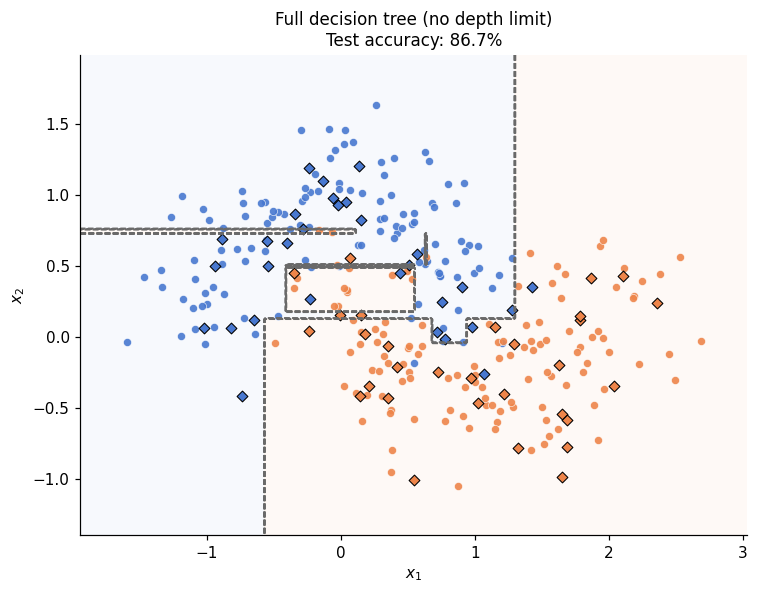

In [5]:
fig, ax = plt.subplots(figsize=(7, 5.5))
plot_boundary(tree_full, X_train, y_train, X_test, y_test,
              title='Full decision tree (no depth limit)', ax=ax)
plt.tight_layout()
plt.show()

Look at the boundary carefully. You should be able to see:

- The staircase structure — every edge of every region is either horizontal or vertical.
- **Tiny isolated "islands"** of one class surrounded by the other, especially in sparse regions. These are leaves created for individual noisy training points. The tree has memorised noise rather than learned structure.

We can also visualise the tree structure itself. With a full tree this gets large, but it illustrates the recursive splitting:

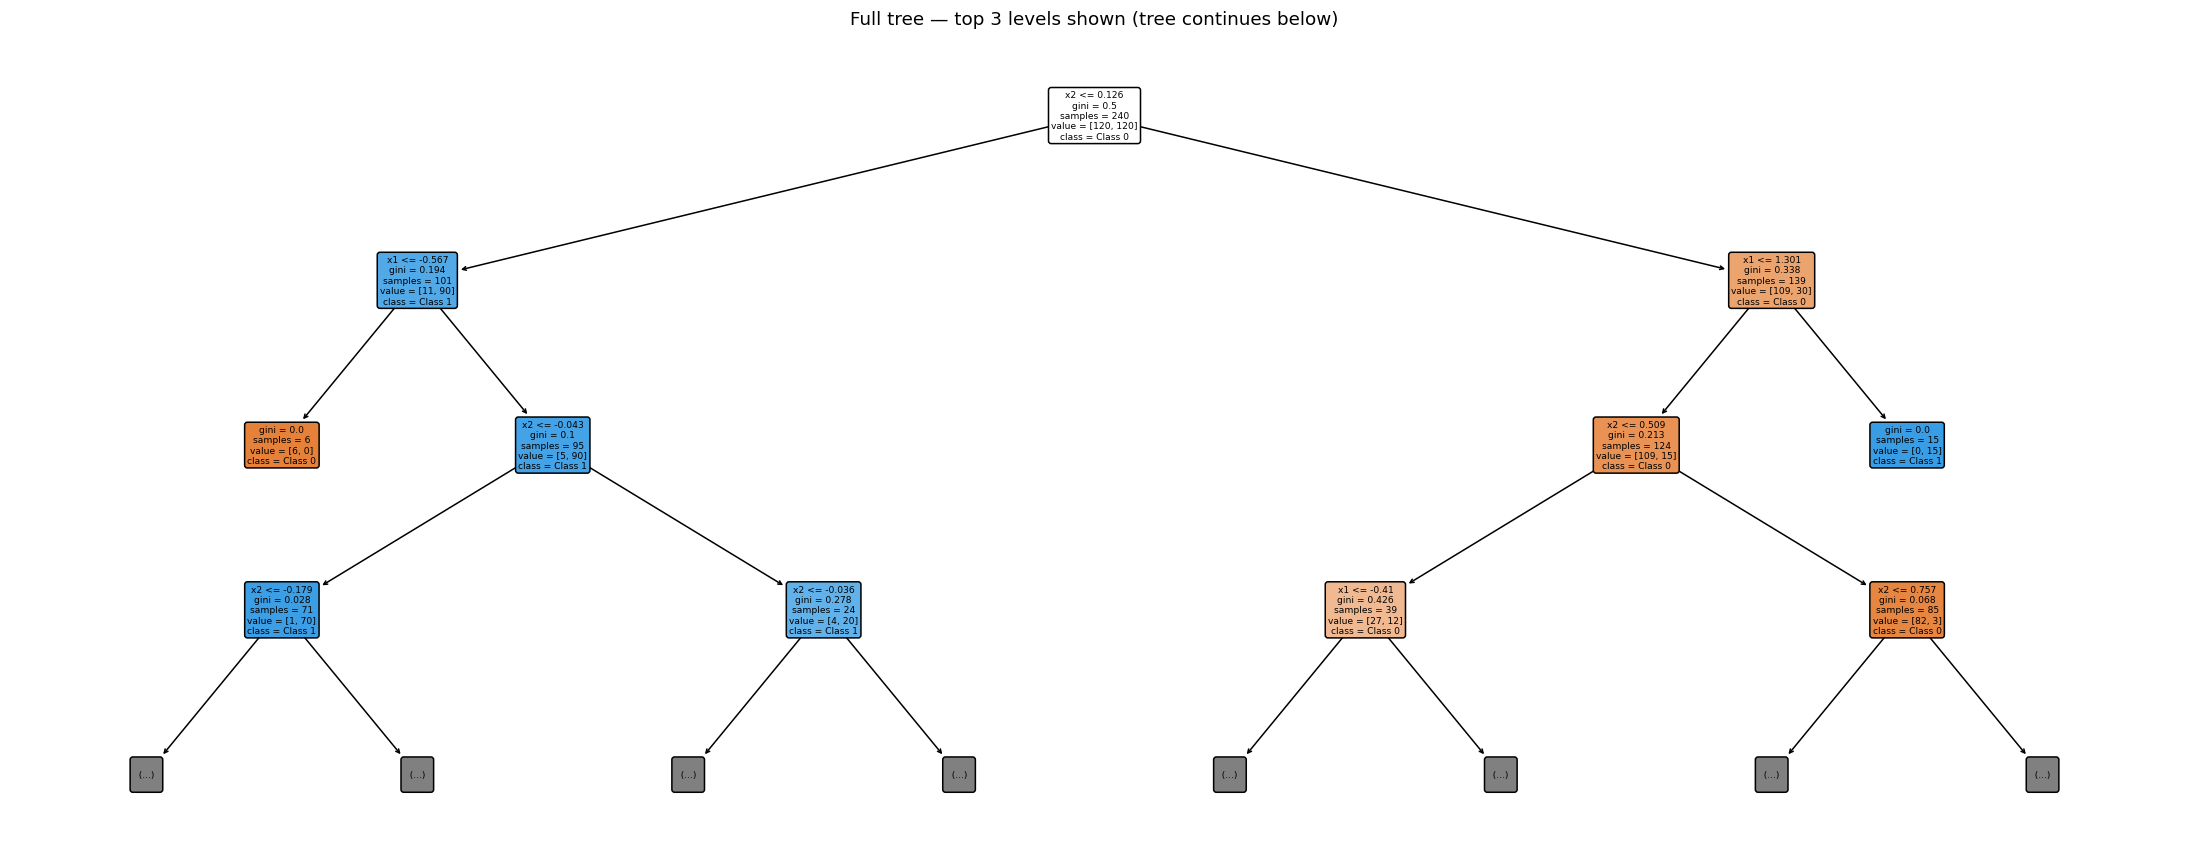

In [6]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(tree_full,
          feature_names=['x1', 'x2'],
          class_names=['Class 0', 'Class 1'],
          filled=True, rounded=True, fontsize=6,
          max_depth=3,       # show only the top 3 levels for readability
          ax=ax, impurity=True)
ax.set_title('Full tree — top 3 levels shown (tree continues below)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Method 2 — Pruned Tree via Depth Control

### The problem with the full tree

The full tree overfits because it is allowed to keep splitting until every leaf is pure, no matter how few points are in that leaf. A leaf containing two training points from the same class is not learning real structure — it is memorising noise.

### The fix: limit the depth

The most direct way to control tree complexity is to simply cap how deep the tree is allowed to grow, using the `max_depth` parameter. A tree of depth $d$ can have at most $2^d$ leaves.

- **Too shallow** (e.g., depth 1 or 2): the tree cannot capture the curved boundary at all — high bias.
- **Too deep** (e.g., depth 10+): the tree overfits, carving out tiny regions for noise — high variance.
- **Just right**: the tree captures the main structure without chasing individual noisy points.

We will sweep over depths 1 through 10, record training and test accuracy at each depth, and pick the depth that maximises test accuracy. The resulting plot directly shows the bias-variance tradeoff as a function of depth.

In [7]:
# Sweep over candidate depths and record train + test accuracy
candidate_depths = list(range(1, 11))
train_accs = []
test_accs  = []
n_leaves   = []

for d in candidate_depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=SEED)
    clf.fit(X_train, y_train)
    train_accs.append(clf.score(X_train, y_train))
    test_accs.append(clf.score(X_test,  y_test))
    n_leaves.append(clf.get_n_leaves())

train_accs = np.array(train_accs)
test_accs  = np.array(test_accs)
n_leaves   = np.array(n_leaves)

best_depth = candidate_depths[np.argmax(test_accs)]
print(f'Best depth     : {best_depth}')
print(f'Leaves at best : {n_leaves[best_depth - 1]}')
print(f'Test accuracy  : {test_accs[best_depth - 1]:.1%}')

Best depth     : 6
Leaves at best : 19
Test accuracy  : 90.0%


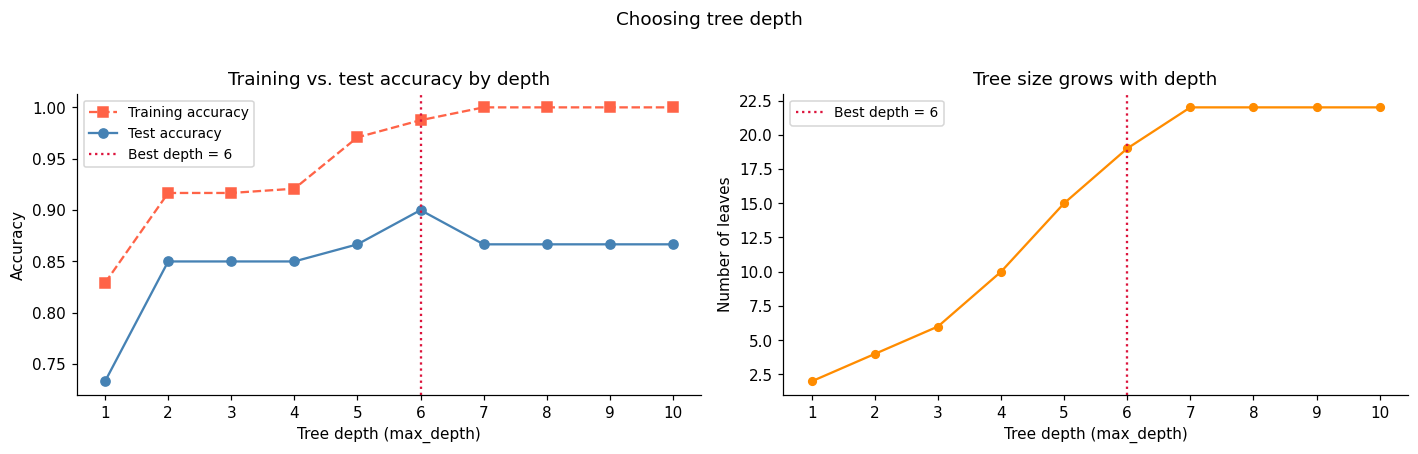

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: accuracy vs depth
axes[0].plot(candidate_depths, train_accs, 's--', color='tomato',    label='Training accuracy')
axes[0].plot(candidate_depths, test_accs,  'o-',  color='steelblue', label='Test accuracy')
axes[0].axvline(best_depth, color='crimson', linestyle=':', linewidth=1.5,
                label=f'Best depth = {best_depth}')
axes[0].set_xlabel('Tree depth (max_depth)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs. test accuracy by depth')
axes[0].set_xticks(candidate_depths)
axes[0].legend(fontsize=9)

# Right: number of leaves vs depth
axes[1].plot(candidate_depths, n_leaves, 'o-', color='darkorange', markersize=5)
axes[1].axvline(best_depth, color='crimson', linestyle=':', linewidth=1.5,
                label=f'Best depth = {best_depth}')
axes[1].set_xlabel('Tree depth (max_depth)')
axes[1].set_ylabel('Number of leaves')
axes[1].set_title('Tree size grows with depth')
axes[1].set_xticks(candidate_depths)
axes[1].legend(fontsize=9)

plt.suptitle('Choosing tree depth', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Reading these plots:**

- **Training accuracy** (red) climbs monotonically — more depth always fits the training data better, reaching 100% for the full tree.
- **Test accuracy** (blue) rises at first, then peaks and declines. To the left of the peak the tree is too simple (high bias); to the right it is memorising noise (high variance).
- The best depth sits at the peak of the test accuracy curve. This is the bias-variance tradeoff made directly visible.

Note that we are using the test set to choose the depth here, which is slightly optimistic — in a real analysis you would use cross-validation to avoid this. But for the purposes of this lab it gives a clean, interpretable picture.

In [9]:
# Fit the pruned tree at the best depth
tree_pruned = DecisionTreeClassifier(max_depth=best_depth, random_state=SEED)
tree_pruned.fit(X_train, y_train)

print(f'Pruned tree depth : {tree_pruned.get_depth()}')
print(f'Number of leaves  : {tree_pruned.get_n_leaves()}')
print(f'Training accuracy : {tree_pruned.score(X_train, y_train):.1%}')
print(f'Test accuracy     : {tree_pruned.score(X_test,  y_test):.1%}')
print('\nTree structure:')
print(export_text(tree_pruned, feature_names=['x1', 'x2']))

Pruned tree depth : 6
Number of leaves  : 19
Training accuracy : 98.8%
Test accuracy     : 90.0%

Tree structure:
|--- x2 <= 0.13
|   |--- x1 <= -0.57
|   |   |--- class: 0
|   |--- x1 >  -0.57
|   |   |--- x2 <= -0.04
|   |   |   |--- x2 <= -0.18
|   |   |   |   |--- class: 1
|   |   |   |--- x2 >  -0.18
|   |   |   |   |--- x2 <= -0.18
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- x2 >  -0.18
|   |   |   |   |   |--- class: 1
|   |   |--- x2 >  -0.04
|   |   |   |--- x2 <= -0.04
|   |   |   |   |--- x1 <= 0.21
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- x1 >  0.21
|   |   |   |   |   |--- class: 0
|   |   |   |--- x2 >  -0.04
|   |   |   |   |--- x1 <= 0.94
|   |   |   |   |   |--- x1 <= 0.68
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- x1 >  0.68
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- x1 >  0.94
|   |   |   |   |   |--- class: 1
|--- x2 >  0.13
|   |--- x1 <= 1.30
|   |   |--- x2 <= 0.51
|   |   |   |--- x1 <= -0.41
|   |   |

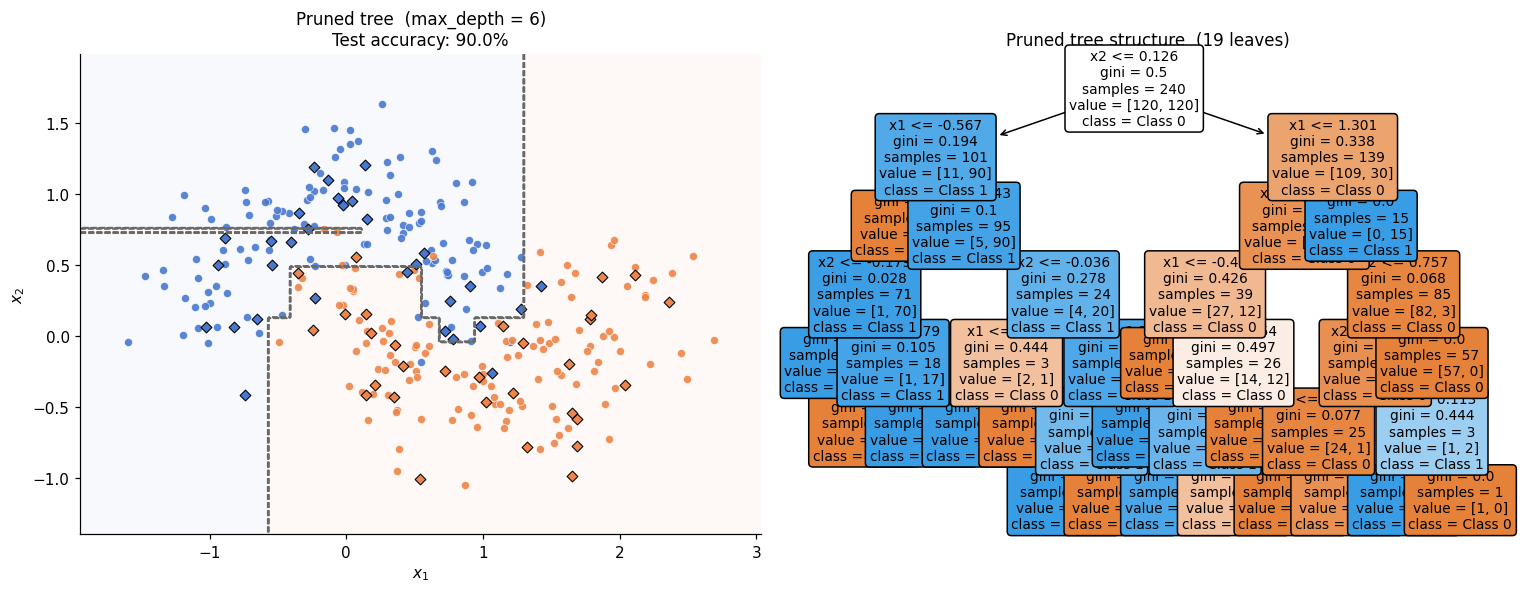

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: decision boundary
plot_boundary(tree_pruned, X_train, y_train, X_test, y_test,
              title=f'Pruned tree  (max_depth = {best_depth})', ax=axes[0])

# Right: tree diagram (small enough to read at best_depth)
plot_tree(tree_pruned,
          feature_names=['x1', 'x2'],
          class_names=['Class 0', 'Class 1'],
          filled=True, rounded=True, fontsize=9,
          ax=axes[1])
axes[1].set_title(f'Pruned tree structure  ({tree_pruned.get_n_leaves()} leaves)', fontsize=11)

plt.tight_layout()
plt.show()

Compare this boundary to the full tree above. The pruned tree has far fewer leaves, and the boundary is noticeably cleaner — the tiny isolated islands are gone. The tree has given up some training fit in exchange for a boundary that generalises better.

The tree diagram on the right is now small enough to read completely. You can trace the path for any point: start at the root, follow the yes/no branches based on $x_1$ and $x_2$, and arrive at a leaf with a class prediction.

---


In [ ]:
logreg = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
logreg.fit(X_train, y_train)

print(f'Training accuracy : {logreg.score(X_train, y_train):.1%}')
print(f'Test accuracy     : {logreg.score(X_test,  y_test):.1%}')

b0 = logreg.intercept_[0]
b1, b2 = logreg.coef_[0]
print(f'\nFitted boundary: {b1:.3f}·x₁ + {b2:.3f}·x₂ + {b0:.3f} = 0')

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5.5))
plot_boundary(logreg, X_train, y_train, X_test, y_test,
              title='Logistic regression', ax=ax)

# Overlay the analytic decision line
x1r = np.linspace(X_train[:, 0].min() - 0.3, X_train[:, 0].max() + 0.3, 300)
ax.plot(x1r, -(b0 + b1 * x1r) / b2, 'k-', linewidth=2, label='Decision boundary')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The straight line slices diagonally through the data. It does a reasonable job in the middle of the plot but systematically misclassifies points in the inner curves of each crescent — the regions where the true boundary curves away from any straight line.

This is not a failure of logistic regression as a method — it is working exactly as designed. The problem is that the method's assumptions (linear boundary) do not match the structure of this data.

---
## Method 4 — Random Forest

### The idea: average many trees

A single pruned tree is better than the full tree, but it still has variance — a slightly different training set would produce a somewhat different staircase boundary. The **random forest** addresses this by training many trees and combining their votes.

Each tree in the forest is trained on a **bootstrap resample** of the training data (a random sample of the same size, drawn *with replacement*). At each split, the tree is only allowed to consider a random subset of $m$ features. These two sources of randomness make the trees different from one another.

The final prediction is a **majority vote** across all $B$ trees.

**Why does this help?** From the lecture notes, the variance of the average of $B$ predictions is:
$$\mathrm{Var}\!\left(\frac{1}{B}\sum_{b=1}^B \hat{f}_b(x)\right) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$
where $\sigma^2$ is each tree's variance and $\rho$ is the correlation between trees. As $B$ grows, the second term shrinks toward zero. The random feature subsampling lowers $\rho$, which lowers the first term as well. Both effects reduce variance.

**Visual prediction:** as we add more trees, the jagged staircase should smooth out into a more stable boundary.

In [ ]:
# Watch the boundary evolve as we add more trees
B_values = [1, 10, 50, 200]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, B in zip(axes, B_values):
    rf = RandomForestClassifier(n_estimators=B, max_features='sqrt', random_state=SEED)
    rf.fit(X_train, y_train)
    plot_boundary(rf, X_train, y_train, X_test, y_test,
                  title=f'Random forest  B = {B}', ax=ax)

plt.suptitle('Boundary smooths as more trees are added', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Final random forest with B = 200
rf_final = RandomForestClassifier(n_estimators=200, max_features='sqrt', random_state=SEED)
rf_final.fit(X_train, y_train)

print(f'Training accuracy : {rf_final.score(X_train, y_train):.1%}')
print(f'Test accuracy     : {rf_final.score(X_test,  y_test):.1%}')

With $B = 1$ the forest is just a single tree, and the boundary is jagged. By $B = 10$ it is already smoother. By $B = 200$ the boundary closely follows the crescent gap — still made of axis-aligned steps at the microscopic level, but averaging has softened them into something that looks curved.

---
## Summary: All Four Methods Side by Side

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(23, 5.5))

# Full tree
plot_boundary(tree_full, X_train, y_train, X_test, y_test,
              title=f'Full tree\n({tree_full.get_n_leaves()} leaves, overfit)', ax=axes[0])

# Pruned tree
plot_boundary(tree_pruned, X_train, y_train, X_test, y_test,
              title=f'Pruned tree (depth = {best_depth})\n({tree_pruned.get_n_leaves()} leaves)', ax=axes[1])

# Logistic regression with analytic line
plot_boundary(logreg, X_train, y_train, X_test, y_test,
              title='Logistic regression\n(linear boundary)', ax=axes[2])
x1r = np.linspace(X_train[:,0].min()-0.3, X_train[:,0].max()+0.3, 300)
axes[2].plot(x1r, -(b0 + b1*x1r)/b2, 'k-', linewidth=1.8)

# Random forest
plot_boundary(rf_final, X_train, y_train, X_test, y_test,
              title='Random forest (B = 200)\n(smooth boundary)', ax=axes[3])

plt.suptitle('Four methods on the Two Moons dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print accuracy table
print('\n' + '='*52)
print(f'{"Method":<28} {"Train":>10} {"Test":>10}')
print('='*52)
for clf, name in [
    (tree_full,   'Full tree'),
    (tree_pruned, f'Pruned tree (depth={best_depth})'),
    (logreg,      'Logistic regression'),
    (rf_final,    'Random forest (B=200)'),
]:
    tr = clf.score(X_train, y_train)
    te = clf.score(X_test,  y_test)
    print(f'{name:<28} {tr:>10.1%} {te:>10.1%}')
print('='*52)

---
## Reflection Questions

Write your answers in new markdown cells below each question.

---

**Q1.** The full tree achieves 100% training accuracy but lower test accuracy than the pruned tree. Explain in your own words what the full tree is "learning" that the pruned tree is not — and why that extra learning hurts rather than helps when applied to new data.

---

**Q2.** Look at the accuracy table. Logistic regression has lower test accuracy than the trees and the random forest on this dataset. Does that mean logistic regression is a worse method in general? Describe a dataset where you would expect logistic regression to outperform a decision tree — what would that data look like?

---

*Math 280 | UC Merced | Spring 2026 | S. Sindi*